## Student Performance Analysis Project

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"]=(10,6)
sns.set_style("whitegrid")


## Load Dataset

In [2]:
df = pd.read_excel("student.xlsx")
df.head()

,First Name,Email ID,Quantity,Events,Attendee Status,College Name,How did you come to know about this event?,"Specify in ""Others"" (how did you come to know about this event)",Designation,Year of Graduation,City,CGPA,Experience with python (Months),Family Income,Expected salary (Lac),Leadership- skills
0,ANIKET,aniket@xyz.com,1,Art of Resume Building,Attending,D Y PATIL INSTITUTE OF MCA AND MANAGEMENT AKUR...,Email,NaN,Students,2024,Patna,6.7,7,7 Lakh+,6,yes
1,Dhanshree,dhanshree@xyz.com,1,Art of Resume Building,Attending,AP SHAH INSTITUTE OF TECHNOLOGY,Others,College,Students,2024,Amravati,8.2,3,0-2 Lakh,7,no
2,Dhiraj,dhiraj@xyz.com,1,Art of Resume Building,Attending,Don Bosco College of Engineering Fatorda Goa,Email,NaN,Students,2023,Kunrool,6.5,4,5-7 Lakh,7,no
3,Pooja,pooja@xyz.com,1,Art of Resume Building,Attending,Pillai College of Engineering New Panvel,Email,NaN,Students,2025,Tirupati,8.7,7,2-5 Lakh,8,no
4,Aayush,aayush@xyz.com,1,Art of Resume Building,Attending,St Xavier's College,Instagram | LinkedIn | Cloud Counselage Website,NaN,Students,2024,Vijaywada,9.1,3,0-2 Lakh,10,yes


## 1. How many unique students are included in the dataset?

In [3]:
unique_students = df["Email ID"].nunique()

print("Unique Students :", unique_students)

Unique Students : 2157


## 2. What is the average GPA of the students?

In [4]:
avg_gpa = df["CGPA"].mean()

print("Average GPA :", round(avg_gpa,2))

Average GPA : 8.04


## 3. What is the distribution of students across different graduation years?

Year of Graduation
2023    1536
2024    1511
2025    1292
2026     555
Name: count, dtype: int64


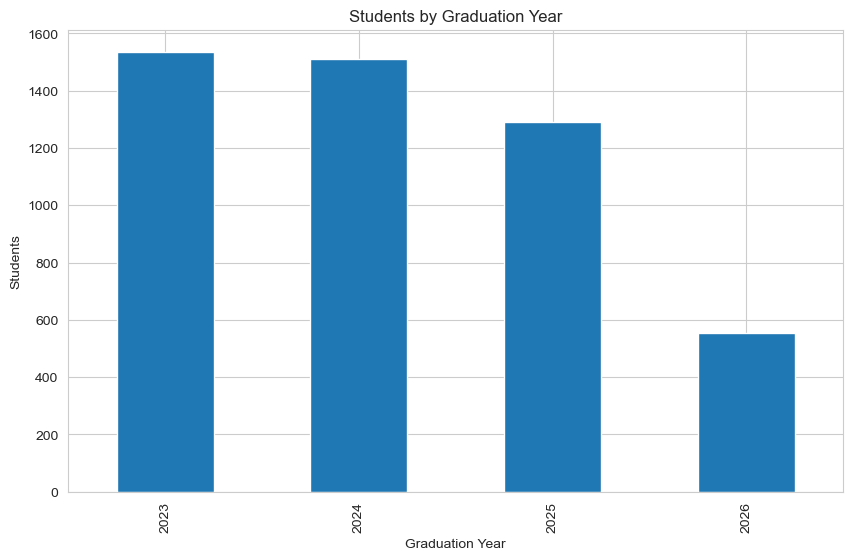

In [5]:
grad_year = df["Year of Graduation"].value_counts().sort_index()

print(grad_year)

grad_year.plot(kind="bar")
plt.title("Students by Graduation Year")
plt.xlabel("Graduation Year")
plt.ylabel("Students")
plt.show()

## 4. What is the distribution of students' experience with Python programming?

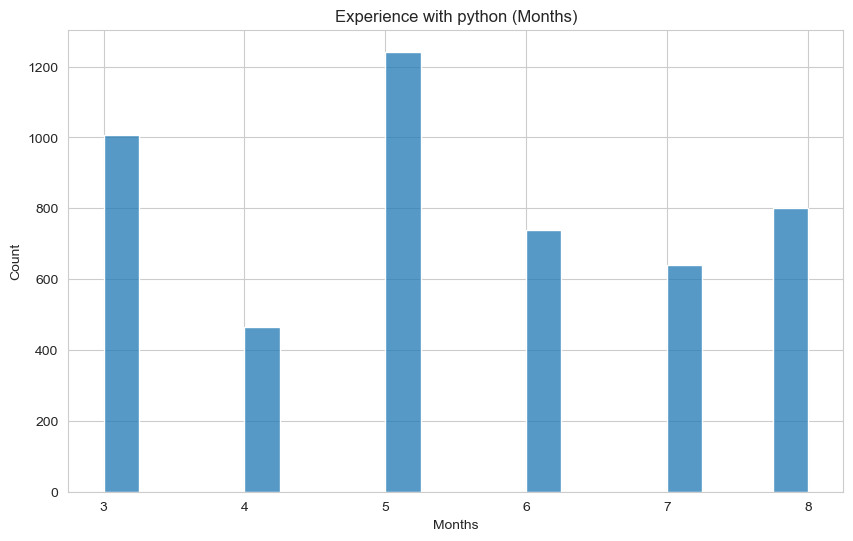

In [6]:
sns.histplot(df["Experience with python (Months)"], bins=20)

plt.title("Experience with python (Months)")
plt.xlabel("Months")
plt.show()

## 5. What is the average family income of the students?

In [7]:
df["Family Income"].value_counts()

Family Income
0-2 Lakh    4525
2-5 Lakh     200
7 Lakh+       89
5-7 Lakh      80
Name: count, dtype: int64

## 6. How does the GPA vary among different colleges? (Top 5)

College Name
THAKUR INSTITUTE OF MANAGEMENT STUDIES, CAREER DEVELOPMENT & RESEARCH - [TIMSCDR]    8.585714
St Xavier's College                                                                  8.578571
B. K. Birla College of Arts, Science & Commerce (Autonomous), Kalyan                 8.456410
Symbiosis Institute of Technology, Pune                                              8.303448
AP SHAH INSTITUTE OF TECHNOLOGY                                                      8.283333
Name: CGPA, dtype: float64


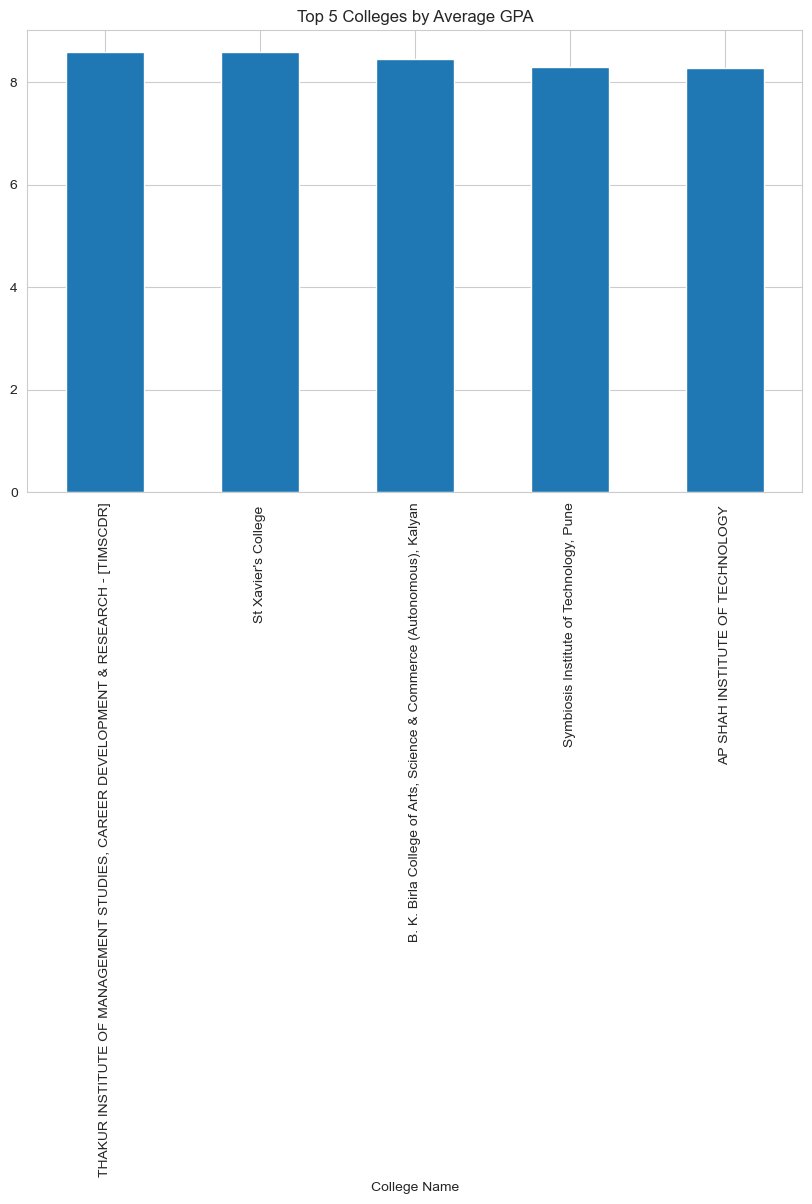

In [8]:
college = (df.groupby("College Name")["CGPA"]
             .mean()
             .sort_values(ascending=False)
             .head(5))

print(college)

college.plot(kind="bar")
plt.title("Top 5 Colleges by Average GPA")
plt.show()

## 7. Are there any outliers in the quantity (courses completed) attribute?

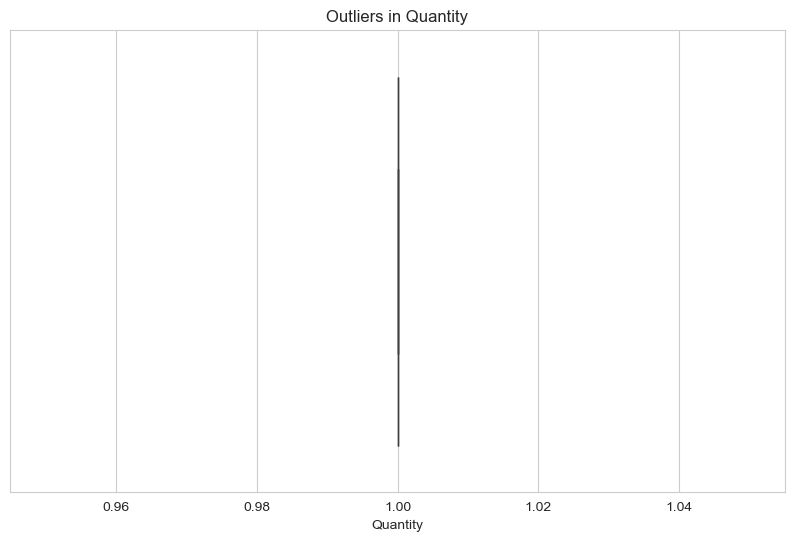

In [9]:
sns.boxplot(x=df["Quantity"])

plt.title("Outliers in Quantity")
plt.show()

## 8. What is the average GPA for students from each city?

City
Kolhapur     8.557143
Raipur       8.507143
Sonipat      8.464286
Gurugram     8.459259
Puri         8.450000
               ...   
Panipat      7.615385
Nashik       7.592857
Daman        7.421429
Rewari       7.392308
New Delhi    7.307143
Name: CGPA, Length: 177, dtype: float64


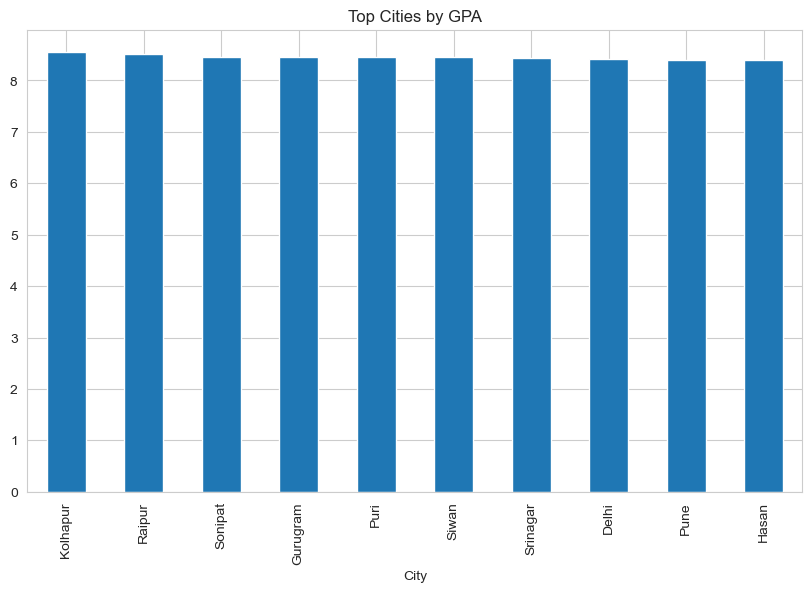

In [10]:
city = df.groupby("City")["CGPA"].mean().sort_values(ascending=False)

print(city)

city.head(10).plot(kind="bar")
plt.title("Top Cities by GPA")
plt.show()

## 10. How many students are from various cities? (Solve using data visualisation 

City
Chandigarh    57
Siuri         56
Talmuk        56
Gonda         56
Sikar         52
              ..
Panipat       13
Rohtak        13
Rewari        13
Karnal        13
Amravati       6
Name: count, Length: 177, dtype: int64


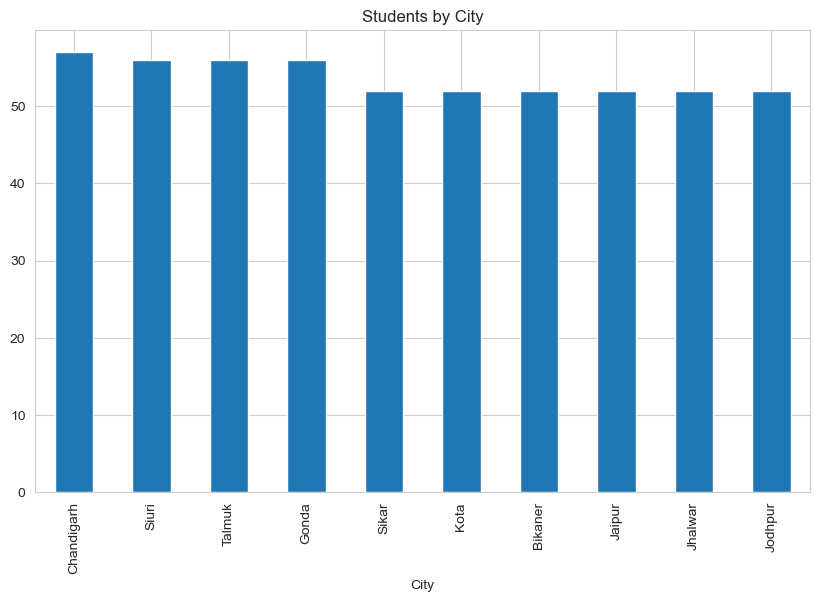

In [11]:
city_count = df["City"].value_counts()

print(city_count)

city_count.head(10).plot(kind="bar")
plt.title("Students by City")
plt.show()

## 11. How does the expected salary vary based on GPA, family income, and Python experience?

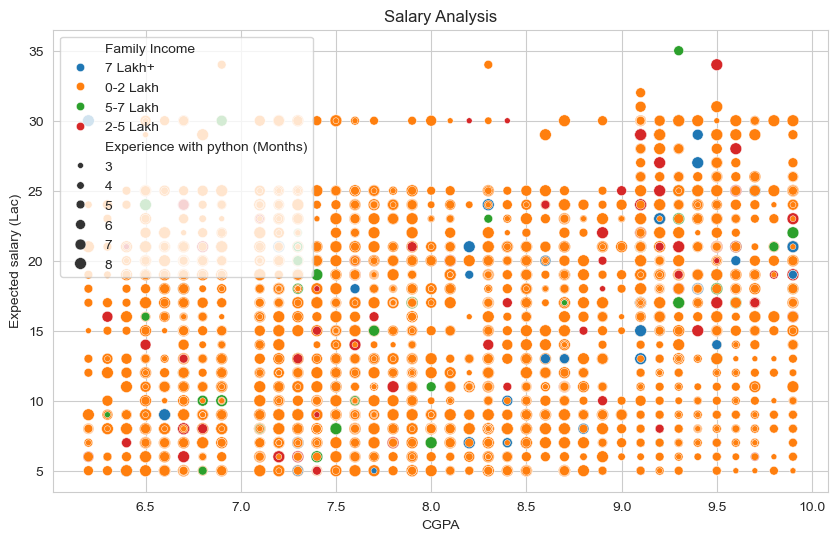

In [12]:
sns.scatterplot(
    data=df,
    x="CGPA",
    y="Expected salary (Lac)",
    hue="Family Income",
    size="Experience with python (Months)"
)

plt.title("Salary Analysis")
plt.show()

## 12. Which event tend to attracts more students from specific fields of study?

Events
Product Design & Full Stack                    842
Internship Program(IP) Success Conclave        797
Art of Resume Building                         478
Data Visualization using Power BI              455
Talk on Skill and Employability Enhancement    379
Skill and Employability Enhancement            318
IS DATA SCIENCE FOR YOU?                       306
Hello ML and DL                                262
KYC - Know Your CCPC                           205
IAC - Q&A                                      146
The SDLC & their transformations               142
Artificial Intelligence                        125
The Agile Ways of Working                      121
RPA: A Boon or A Bane                          114
Product Marketing                              112
Transformation with DevOps: The Easy Way        92
Name: count, dtype: int64


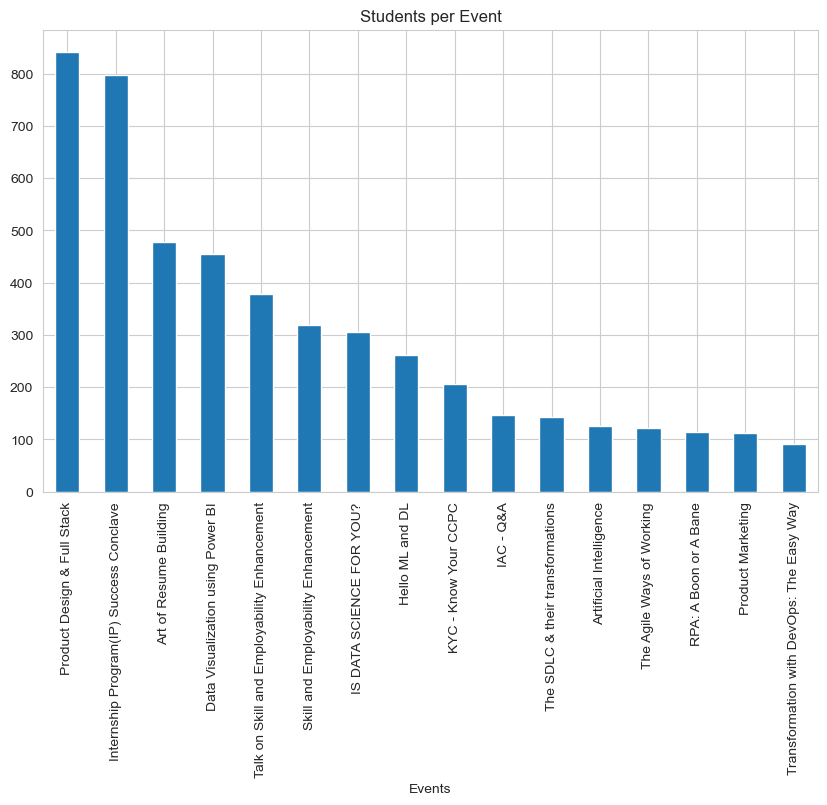

In [13]:
events = df["Events"].value_counts()

print(events)

events.plot(kind="bar")
plt.title("Students per Event")
plt.show()

## 13. Do students with leadership skills have higher GPAs or better salary expectations?

                        CGPA  Expected salary (Lac)
Leadership- skills                                 
no                  8.040444              13.795098
no                  8.034816              14.407975
yes                 8.036787              13.971796


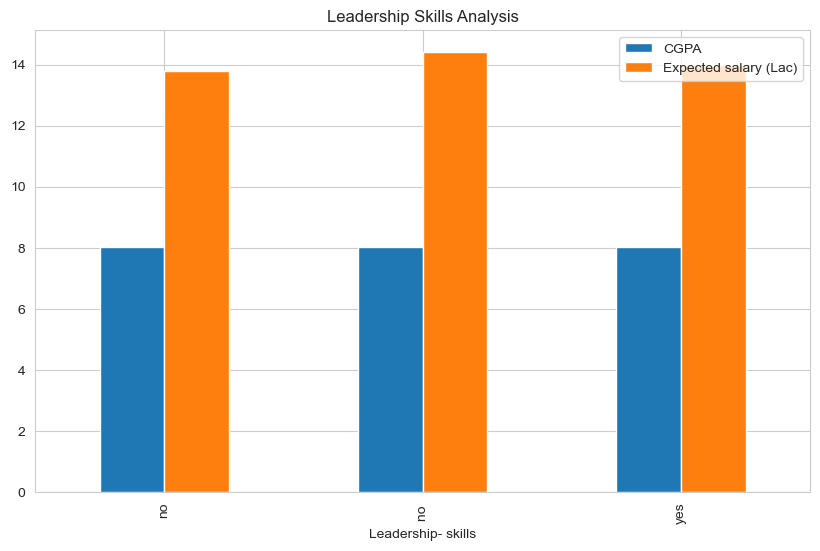

In [14]:
leadership = df.groupby("Leadership- skills")[["CGPA","Expected salary (Lac)"]].mean()

print(leadership)

leadership.plot(kind="bar")
plt.title("Leadership Skills Analysis")
plt.show()

## 14. How many students are graduating by the end of 2024?

In [15]:
students2024 = df[df["Year of Graduation"]<=2024]

print("Students Graduating by 2024 :", len(students2024))

Students Graduating by 2024 : 3047


## 15. Which promotion channel brings more student participation for the event?

How did you come to know about this event?
Whatsapp                                                                                       1067
Email                                                                                           438
SPOC/ College Professor                                                                         326
Others                                                                                          153
Cloud Counselage Website                                                                        129
                                                                                               ... 
Youtube | Instagram | Whatsapp | Email                                                            1
LinkedIn | Email | Telegram                                                                       1
Youtube | Email | Others                                                                          1
Youtube | Facebook | Instagram | LinkedIn | Whatsapp | Em

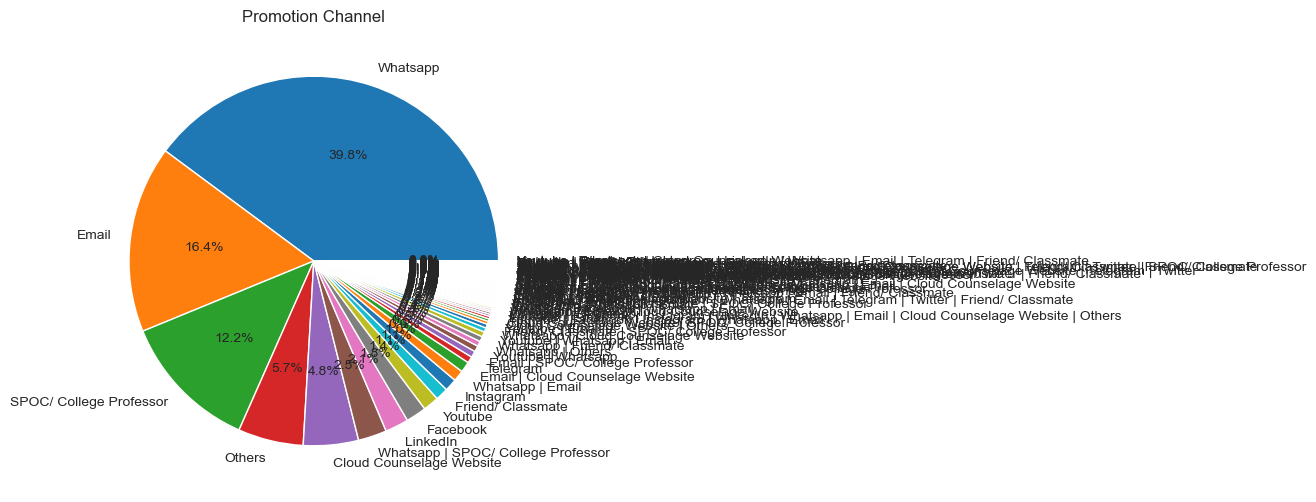

In [16]:
promotion = df["How did you come to know about this event?"].value_counts()

print(promotion)

promotion.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Promotion Channel")
plt.show()

## 16. Find the total number of students who attended Data Science events.

In [17]:
data_science = df[df["Events"].str.contains("Data Science", case=False, na=False)]

print("Students Attended Data Science Events")

print(len(data_science))

Students Attended Data Science Events
306


## 17. Do students with high CGPA and more experience in language those who had high expectations for salary(Avg)?

Average Salary
16.9203187250996


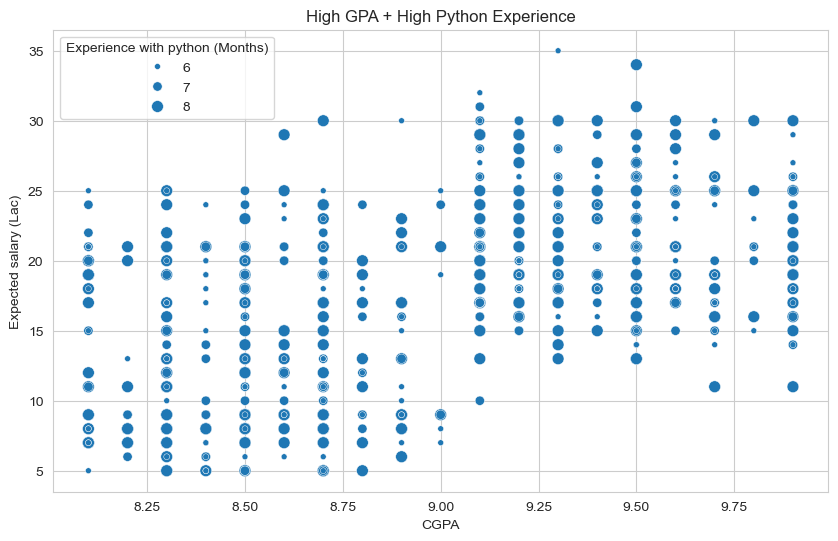

In [19]:
high = df[
    (df["CGPA"]>=df["CGPA"].mean()) &
    (df["Experience with python (Months)"]>=df["Experience with python (Months)"].mean())
]

print("Average Salary")

print(high["Expected salary (Lac)"].mean())

sns.scatterplot(
    data=high,
    x="CGPA",
    y="Expected salary (Lac)",
    size="Experience with python (Months)"
)

plt.title("High GPA + High Python Experience")
plt.show()